# Stage 1 Fairness

This notebook is reserved for fairness diagnostics on the Stage 1 dabbler classifier. The intended analysis is to compare prediction quality and continuation rates across demographic groups while keeping the Stage 1 target definition fixed.

Recommended checks include group representation, label balance, false-positive and false-negative rates, and whether performance differences remain when small groups are filtered out. These results should be interpreted as diagnostic evidence, not as causal claims about demographic attributes.


### Setup

In [1]:
import os
from pathlib import Path

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["BOOST_COMPUTE_USE_OFFLINE_CACHE"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

import lightgbm as lgb

try:
    import torch
    CUDA_AVAILABLE = torch.cuda.is_available()
except ModuleNotFoundError:
    CUDA_AVAILABLE = False

PROJECT_ROOT = Path.cwd()

from src.preprocess import STAGE1_BEHAVIORAL_FEATURES, build_stage1_dataset
from src import metrics_utils as metrics
from src.fairness_utils_stage1 import *

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
LGBM_DEVICE = "gpu" if CUDA_AVAILABLE else "cpu"
print("LightGBM device:", LGBM_DEVICE)


LightGBM device: gpu


In [3]:
stage1 = build_stage1_dataset(DATA_DIR)
df = stage1.df
feature_cols = stage1.feature_cols

print(f"rows: {len(df):,}")
print(f"features: {len(feature_cols):,}")
print(f"came_back rate: {df['came_back'].mean():.3f}")
print(df["came_back"].value_counts().rename({0: "left", 1: "came_back"}))

df.head()

rows: 22,466
features: 88
came_back rate: 0.608
came_back
came_back    13652
left          8814
Name: count, dtype: int64


,user_id,total_events_0_2,n_active_days_0_2,n_click_events_0_2,n_view_events_0_2,n_sessions_0_2,n_topics_event_0_2,mean_hour_0_2,std_hour_0_2,total_transactions_0_2,...,school_Passerelle,school_Passerelle BM/FM,school_Sekundarschule P,school_UG,school_Unknown,school_Vorkurs PH für Berufsleute,school_Vorkurs Pädagogik,school_WMS,school_andere,came_back
0,387604,2.0,2.0,0.0,2.0,0.0,0.0,9.000000,5.656854,2,...,0,0,0,0,1,0,0,0,0,1
1,387605,12.0,1.0,7.0,5.0,2.0,2.0,6.000000,0.000000,5,...,0,0,0,0,1,0,0,0,0,1
2,387608,101.0,2.0,35.0,66.0,2.0,1.0,8.603960,1.225391,34,...,0,0,0,0,1,0,0,0,0,1
3,387613,11.0,1.0,3.0,8.0,1.0,1.0,12.000000,0.000000,2,...,0,0,0,0,1,0,0,0,0,1
4,387615,348.0,6.0,76.0,272.0,2.0,1.0,9.784483,2.961246,37,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
train_val_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["came_back"],
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_val_df["came_back"],
)

print("train:", train_df.shape)
print("val:  ", val_df.shape)
print("test: ", test_df.shape)


train: (14377, 90)
val:   (3595, 90)
test:  (4494, 90)


In [ ]:
model_lgb = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    class_weight="balanced",
    device=LGBM_DEVICE,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=-1,
)

model_lgb.fit(
    train_df[feature_cols],
    train_df["came_back"],
    eval_set=[(val_df[feature_cols], val_df["came_back"])],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=True)],
)


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[415]	valid_0's auc: 0.778404	valid_0's binary_logloss: 0.56074


LGBMClassifier(class_weight='balanced', device='cpu', learning_rate=0.05,
               max_depth=6, n_estimators=500, n_jobs=1, random_state=42,
               verbose=-1)

In [ ]:
val_prob = model_lgb.predict_proba(val_df[feature_cols])[:, 1]
test_prob = model_lgb.predict_proba(test_df[feature_cols])[:, 1]

best_threshold, val_f1 = metrics.best_threshold_by_f1(val_df["came_back"], val_prob)
test_metrics = metrics.binary_metrics(test_df["came_back"], test_prob, best_threshold)

print(f"validation best threshold: {best_threshold:.3f}")
print(f"validation F1: {val_f1:.4f}")
metrics.print_metrics(test_metrics, prefix="test_")

print("Confusion matrix:")
print(confusion_matrix(test_df["came_back"], test_prob > best_threshold))

print("Classification report:")
print(classification_report(
    test_df["came_back"],
    test_prob > best_threshold,
    target_names=["left", "came_back"],
))

validation best threshold: 0.345
validation F1: 0.7892
test_roc_auc: 0.7711
test_f1: 0.7909
test_precision: 0.7091
test_recall: 0.8942
test_threshold: 0.3449
Confusion matrix:
[[ 761 1002]
 [ 289 2442]]
Classification report:
              precision    recall  f1-score   support

        left       0.72      0.43      0.54      1763
   came_back       0.71      0.89      0.79      2731

    accuracy                           0.71      4494
   macro avg       0.72      0.66      0.67      4494
weighted avg       0.72      0.71      0.69      4494



In [ ]:
test_yhat = (test_prob > best_threshold).astype(int)

fairness_df = test_df.copy()

fairness_df["y_true"] = test_df["came_back"].values
fairness_df["y_pred"] = test_yhat
fairness_df["y_prob"] = test_prob

print(fairness_df.shape)
fairness_df.head()

(4494, 93)


,user_id,total_events_0_2,n_active_days_0_2,n_click_events_0_2,n_view_events_0_2,n_sessions_0_2,n_topics_event_0_2,mean_hour_0_2,std_hour_0_2,total_transactions_0_2,...,school_UG,school_Unknown,school_Vorkurs PH für Berufsleute,school_Vorkurs Pädagogik,school_WMS,school_andere,came_back,y_true,y_pred,y_prob
12890,408986,297.0,1.0,134.0,163.0,11.0,2.0,9.380471,0.486322,56,...,0,0,0,0,0,0,1,1,1,0.653023
11143,405928,47.0,1.0,18.0,29.0,0.0,0.0,12.148936,0.977546,8,...,0,0,0,0,0,0,1,1,1,0.732549
18017,418448,158.0,3.0,54.0,104.0,6.0,2.0,11.379747,0.673498,28,...,0,0,0,0,0,0,1,1,1,0.668754
20467,427464,35.0,2.0,12.0,23.0,1.0,1.0,11.628571,0.490241,3,...,0,0,0,0,0,0,1,1,1,0.380967
10653,405229,43.0,3.0,18.0,25.0,1.0,1.0,12.883721,1.257535,19,...,0,0,0,0,0,0,0,0,1,0.560358


In [ ]:
gender_cols = [
    "gender_FEMALE",
    "gender_MALE",
    "gender_Other",
    "gender_Unknown",
]

fairness_df["gender"] = (
    fairness_df[gender_cols]
    .idxmax(axis=1)
    .str.replace("gender_", "", regex=False)
)

fairness_df[["gender"]].head()

,gender
12890,MALE
11143,FEMALE
18017,FEMALE
20467,FEMALE
10653,FEMALE


In [ ]:
canton_cols = [c for c in fairness_df.columns if c.startswith("canton_")]

fairness_df["canton"] = (
    fairness_df[canton_cols]
    .idxmax(axis=1)
    .str.replace("canton_", "", regex=False)
)

fairness_df[["canton"]].head()

,canton
12890,AG
11143,SG
18017,SG
20467,ZH
10653,ZH


In [ ]:
gender_metrics = compute_group_metrics(
    fairness_df,
    group_col="gender"
)

gender_gaps = print_fairness_report(
    gender_metrics,
    demographic_name="Gender"
)

FAIRNESS REPORT FOR: Gender


,group,n_samples,TPR,FPR,PPV,NPV
0,FEMALE,2412,0.889790,0.566988,0.713279,0.712522
1,MALE,1605,0.903766,0.573190,0.699029,0.750678
2,Other,167,0.841121,0.616667,0.708661,0.575000
3,Unknown,310,0.910053,0.528926,0.728814,0.770270



--- MAXIMUM GAPS ACROSS GROUPS ---
Equalized Odds - TPR gap : 0.0689
Equalized Odds - FPR gap : 0.0877

Predictive Value Parity - PPV gap : 0.0298
Predictive Value Parity - NPV gap : 0.1953


In [ ]:
canton_metrics = compute_group_metrics(
    fairness_df,
    group_col="canton"
)

canton_gaps = print_fairness_report(
    canton_metrics,
    demographic_name="Canton"
)

FAIRNESS REPORT FOR: Canton


,group,n_samples,TPR,FPR,PPV,NPV
0,AG,546,0.937870,0.615385,0.712360,0.792079
1,AR,57,1.000000,1.000000,0.877193,NaN
2,Andere,34,0.714286,0.538462,0.681818,0.500000
3,BE,269,0.865385,0.557522,0.681818,0.704225
4,BL,384,0.798817,0.451163,0.581897,0.776316
5,BS,264,0.658333,0.284722,0.658333,0.715278
6,FL,49,0.814815,0.181818,0.846154,0.782609
7,FR,7,1.000000,0.750000,0.500000,1.000000
8,LU,61,0.903226,0.500000,0.651163,0.833333
9,SG,822,0.965245,0.708995,0.820134,0.714286



--- MAXIMUM GAPS ACROSS GROUPS ---
Equalized Odds - TPR gap : 0.6667
Equalized Odds - FPR gap : 0.8182

Predictive Value Parity - PPV gap : 0.5000
Predictive Value Parity - NPV gap : 1.0000


In [4]:
canton_cols = [c for c in df.columns if c.startswith("canton_")]

df_plot = df.copy()
df_plot["canton"] = (
    df_plot[canton_cols]
    .idxmax(axis=1)
    .str.replace("canton_", "", regex=False)
)

canton_counts = (
    df_plot["canton"]
    .value_counts()
    .reset_index()
)

canton_counts.columns = ["canton", "n_users"]
canton_counts

,canton,n_users
0,ZH,5282
1,SG,4165
2,AG,2618
3,BL,1822
4,SO,1753
5,Unknown,1478
6,BS,1473
7,BE,1445
8,SZ,887
9,SH,418


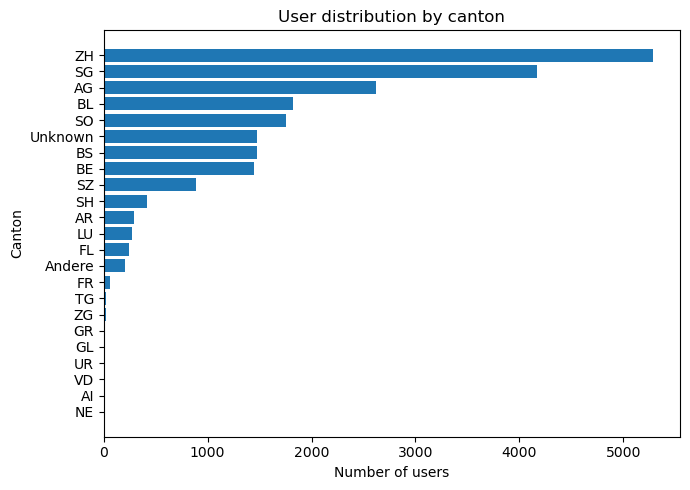

In [5]:
import matplotlib.pyplot as plt

canton_counts_sorted = canton_counts.sort_values("n_users", ascending=True)

plt.figure(figsize=(7, 5))
plt.barh(canton_counts_sorted["canton"], canton_counts_sorted["n_users"])
plt.xlabel("Number of users")
plt.ylabel("Canton")
plt.title("User distribution by canton")
plt.tight_layout()
plt.savefig("src/canton_distribution.png", dpi=300, bbox_inches="tight")
plt.show()